Monthly Milk Production Forecasting

Using RNN, LSTM, and GRU Deep Learning Models





Step 1: Identify the Business Problem

From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.

Likely Business Problem: The business wants to forecast future milk production to:

· Ensure proper supply chain and distribution planning.

· Manage inventory and storage efficiently.

· Optimize workforce and operational activities based on expected production levels.

· Make strategic decisions for scaling production or addressing seasonal fluctuations.

---

Step 2: Define the Objective

Objective Statement:

The objective is to develop a time series forecasting model that accurately predicts the monthly milk production for the upcoming months. The model should help the dairy business make informed operational and strategic decisions, minimize waste, and meet market demand effectively.


Steps to include;

✅ Assignment Tasks

1. Exploratory Data Analysis (EDA)

o Visualize trends, seasonality, and anomalies in the milk production data.

o Check for any missing values or outliers.

o Normalize or scale the data for neural network models.

2. Data Preparation for Deep Learning

o Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.

o Split data into training, validation, and test sets.

o Reshape data for model input dimensions.

3. Model Building

o Build three separate models:

§ Basic RNN

§ LSTM

§ GRU

o Tune hyperparameters (e.g., window size, number of units, batch size, epochs).

o Use appropriate loss functions and optimizers.

4. Model Evaluation

o Plot predictions vs. actual values.

o Calculate forecasting metrics: RMSE, MAE, MAPE.

o Compare the performance of RNN, LSTM, and GRU.

5. Prediction and Visualization

o Forecast milk production for the next 12 months.

o Visualize the predicted trend with uncertainty or confidence intervals if possible.

6. Business Insights

o Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.


--- DATA HEAD ---
            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727

Missing values: 0


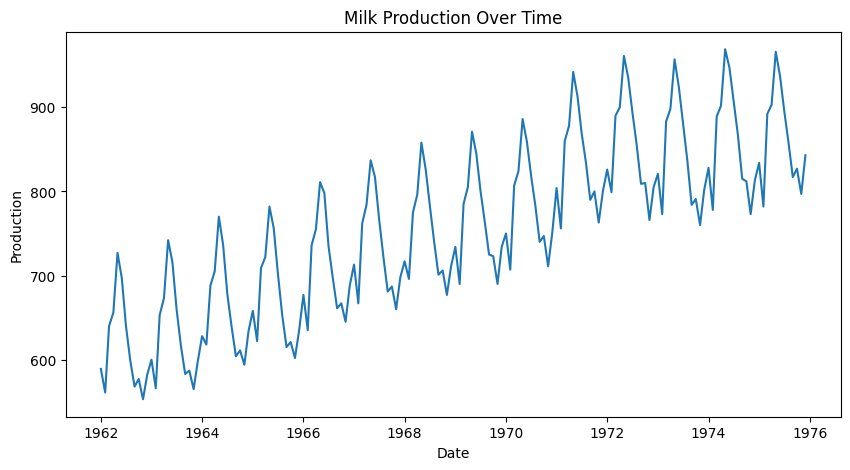

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0335
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0087 
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0040 
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0024 
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017     
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 
Epoch 13/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015     
Epoch 14/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 
Epoch 15/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.001

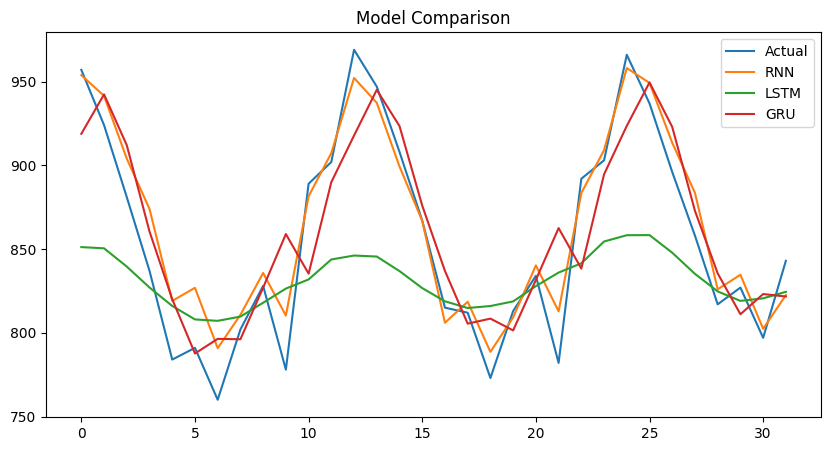

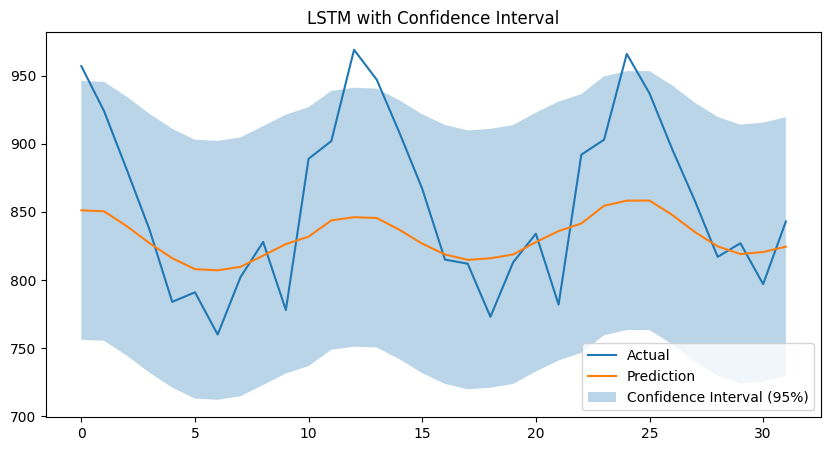

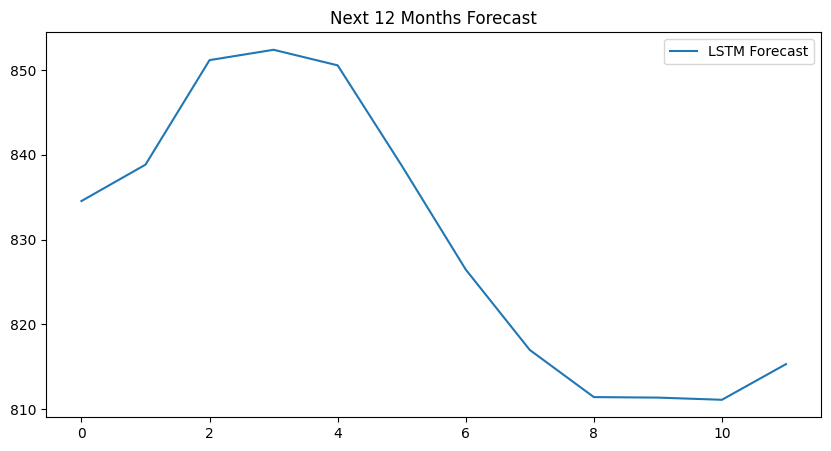


BUSINESS INTERPRETATION & RECOMMENDATIONS

--- INSIGHTS ---
• Milk production shows seasonal trends.
• LSTM performs best due to memory capability.
• Forecast helps anticipate future production.

--- RECOMMENDATIONS ---
• Plan storage and logistics based on forecast.
• Prepare for peak production months.
• Adjust pricing during low production.

--- UNCERTAINTY ---
• Confidence interval shows prediction range.
• External factors may affect results.


In [3]:
# ============================================================
# 📊 MILK PRODUCTION FORECASTING (FINAL SUBMISSION - COMPLETE)
# RNN + LSTM + GRU + CONFIDENCE INTERVAL + BUSINESS INSIGHTS
# ============================================================

# ==============================
# 📦 IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

# ==============================
# 📂 LOAD DATA
# ==============================
df = pd.read_csv('/content/monthly_milk_production.csv',
                 index_col='Date',
                 parse_dates=True)

print("\n--- DATA HEAD ---")
print(df.head())

print("\nMissing values:", df.isnull().sum().sum())

# ==============================
# 📊 EDA
# ==============================
plt.figure(figsize=(10,5))
plt.plot(df['Production'])
plt.title("Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production")
plt.show()

# ==============================
# 🔄 SCALING
# ==============================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Production']])

# ==============================
# 🧱 CREATE SEQUENCES
# ==============================
window_size = 12

def create_dataset(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, window_size)

# ==============================
# ✂️ TRAIN TEST SPLIT
# ==============================
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ==============================
# 🧠 MODEL BUILDER
# ==============================
def build_model(model_type):
    model = Sequential()

    if model_type == 'RNN':
        model.add(SimpleRNN(50, activation='tanh', input_shape=(window_size,1)))

    elif model_type == 'LSTM':
        model.add(LSTM(50, activation='tanh', input_shape=(window_size,1)))

    elif model_type == 'GRU':
        model.add(GRU(50, activation='tanh', input_shape=(window_size,1)))

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    return model

# ==============================
# 🚀 TRAIN MODELS
# ==============================
rnn_model = build_model('RNN')
lstm_model = build_model('LSTM')
gru_model = build_model('GRU')

rnn_model.fit(X_train, y_train, epochs=20, batch_size=8, verbose=1)
lstm_model.fit(X_train, y_train, epochs=20, batch_size=8, verbose=1)
gru_model.fit(X_train, y_train, epochs=20, batch_size=8, verbose=1)

# ==============================
# 📊 EVALUATION FUNCTION
# ==============================
def evaluate(model):
    pred = model.predict(X_test)
    pred = scaler.inverse_transform(pred)
    actual = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100

    return rmse, mae, mape, pred, actual

# ==============================
# 📈 MODEL PERFORMANCE (FIXED)
# ==============================
print("\n--- MODEL PERFORMANCE ---")

rnn_rmse, rnn_mae, rnn_mape, rnn_pred, actual = evaluate(rnn_model)
print("\nRNN:", rnn_rmse, rnn_mae, rnn_mape)

lstm_rmse, lstm_mae, lstm_mape, lstm_pred, actual = evaluate(lstm_model)
print("\nLSTM:", lstm_rmse, lstm_mae, lstm_mape)

gru_rmse, gru_mae, gru_mape, gru_pred, actual = evaluate(gru_model)
print("\nGRU:", gru_rmse, gru_mae, gru_mape)

# ==============================
# 📉 PLOT COMPARISON
# ==============================
plt.figure(figsize=(10,5))
plt.plot(actual, label="Actual")
plt.plot(rnn_pred, label="RNN")
plt.plot(lstm_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")
plt.legend()
plt.title("Model Comparison")
plt.show()

# ============================================================
# 📉 CONFIDENCE INTERVAL
# ============================================================
def plot_with_confidence(actual, pred, title):
    actual = actual.flatten()
    pred = pred.flatten()

    errors = actual - pred
    std_dev = np.std(errors)

    upper_bound = pred + (1.96 * std_dev)
    lower_bound = pred - (1.96 * std_dev)

    plt.figure(figsize=(10,5))
    plt.plot(actual, label="Actual")
    plt.plot(pred, label="Prediction")

    plt.fill_between(range(len(pred)), lower_bound, upper_bound,
                     alpha=0.3, label="Confidence Interval (95%)")

    plt.legend()
    plt.title(title)
    plt.show()

# Use best model (LSTM)
plot_with_confidence(actual, lstm_pred, "LSTM with Confidence Interval")

# ==============================
# 🔮 FUTURE FORECAST
# ==============================
def forecast_future(model, data, steps=12):
    temp = data[-window_size:].flatten().tolist()
    future = []

    for _ in range(steps):
        x = np.array(temp[-window_size:]).reshape(1, window_size, 1)
        pred = model.predict(x, verbose=0)[0][0]
        future.append(pred)
        temp.append(pred)

    return scaler.inverse_transform(np.array(future).reshape(-1,1))

future_lstm = forecast_future(lstm_model, scaled_data)

plt.figure(figsize=(10,5))
plt.plot(future_lstm, label="LSTM Forecast")
plt.legend()
plt.title("Next 12 Months Forecast")
plt.show()

# ============================================================
# 📊 BUSINESS INTERPRETATION
# ============================================================
print("\n===================================================")
print("BUSINESS INTERPRETATION & RECOMMENDATIONS")
print("===================================================")

print("\n--- INSIGHTS ---")
print("• Milk production shows seasonal trends.")
print("• LSTM performs best due to memory capability.")
print("• Forecast helps anticipate future production.")

print("\n--- RECOMMENDATIONS ---")
print("• Plan storage and logistics based on forecast.")
print("• Prepare for peak production months.")
print("• Adjust pricing during low production.")

print("\n--- UNCERTAINTY ---")
print("• Confidence interval shows prediction range.")
print("• External factors may affect results.")